In [22]:
import pandas as pd

# Column names from the UCI Audiology dataset documentation
url_data = "https://archive.ics.uci.edu/ml/machine-learning-databases/audiology/audiology.standardized.data"

df = pd.read_csv(url_data, header=None, na_values="?")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,61,62,63,64,65,66,67,68,69,70
0,f,mild,f,normal,normal,NaN,t,NaN,f,f,...,f,f,normal,t,a,f,f,f,p1,cochlear_unknown
1,f,moderate,f,normal,normal,NaN,t,NaN,f,f,...,f,f,normal,t,a,f,f,f,p2,cochlear_unknown
2,t,mild,t,NaN,absent,mild,t,NaN,f,f,...,f,f,normal,t,as,f,f,f,p3,mixed_cochlear_age_fixation
3,t,mild,t,NaN,absent,mild,f,NaN,f,f,...,f,f,normal,t,b,f,f,f,p4,mixed_cochlear_age_otitis_media
4,t,mild,f,normal,normal,mild,t,NaN,f,f,...,f,f,good,t,a,f,f,f,p5,cochlear_age


In [23]:
print(df.shape)
df.info()

(200, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 71 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       200 non-null    object
 1   1       200 non-null    object
 2   2       200 non-null    object
 3   3       196 non-null    object
 4   4       197 non-null    object
 5   5       125 non-null    object
 6   6       200 non-null    object
 7   7       4 non-null      object
 8   8       200 non-null    object
 9   9       200 non-null    object
 10  10      200 non-null    object
 11  11      200 non-null    object
 12  12      200 non-null    object
 13  13      200 non-null    object
 14  14      200 non-null    object
 15  15      200 non-null    object
 16  16      200 non-null    object
 17  17      200 non-null    object
 18  18      200 non-null    object
 19  19      200 non-null    object
 20  20      200 non-null    object
 21  21      200 non-null    object
 22  22      200 non-

In [24]:
print(df.isnull().sum())

0     0
1     0
2     0
3     4
4     3
     ..
66    0
67    0
68    0
69    0
70    0
Length: 71, dtype: int64


In [25]:
#replace '?' with NaN
df = df.replace('?', pd.NA)

#drop columns that are mostly missing
df = df.dropna(axis=1, thresh=len(df)*0.5)

#drop remaining rows with missing values
df = df.dropna()

print(df.shape)

(120, 70)


In [26]:
#summary
df.describe(include='all')

,0,1,2,3,4,5,6,8,9,10,...,61,62,63,64,65,66,67,68,69,70
count,120,120,120,120,120,120,120,120,120,120,...,120,120,120,120,120,120,120,120,120,120
unique,2,4,2,3,3,4,2,2,2,2,...,1,1,6,2,5,2,2,1,120,21
top,f,mild,f,normal,normal,mild,f,f,f,f,...,f,f,normal,t,a,f,f,f,p5,cochlear_unknown
freq,78,61,102,60,64,53,86,119,109,116,...,120,120,44,117,96,119,118,120,1,31


Most columns in this dataset are categorical (yes/no or test result categories) rather than numeric, which is typical for clinical audiology test data.

In [27]:
import matplotlib.pyplot as plt

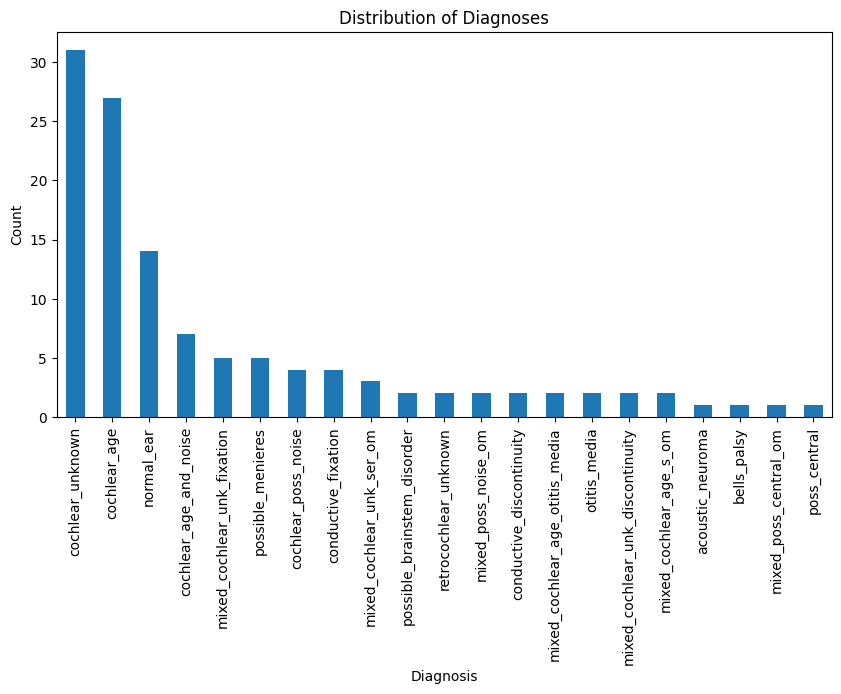

In [28]:
df.iloc[:, -1].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Distribution of Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

Some diagnosis categories appear much more frequently than others, showing the dataset is imbalanced across diagnosis types.

In [29]:
# Check the actual column names first
print(df.columns.tolist())

[0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]


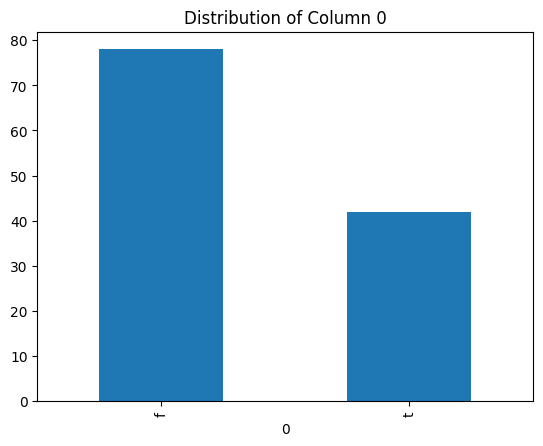

In [30]:
df[0].value_counts().plot(kind='bar')
plt.title("Distribution of Column 0")
plt.show()

Column 0 is a binary indicator (true/false). Most patients (about 78) have a value of 'f', while fewer (about 42) have 't', showing an imbalance in this feature.